notebook ini mendokumentasikan eksplorasi awal terhadap dataset gejala penyakit sebelum masuk ke tahap modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("../data/Training.csv")
test = pd.read_csv("../data/Testing.csv")

# Kolom "Unnamed: 133" adalah artefak export CSV yang kosong -> buang
train = train.drop(columns=[c for c in train.columns if "Unnamed" in c])

print("Shape Training:", train.shape)
print("Shape Testing :", test.shape)
train.head()

Shape Training: (4920, 133)
Shape Testing : (42, 133)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


kualitas data

In [2]:
print("missing values:", train.isnull().sum().sum())
print("baris duplikast persis:", train.duplicated().sum())
print("kombinasi gejala unik:", train.drop_duplicates().shape[0], "dari", len(train), "baris")

missing values: 0
baris duplikast persis: 4616
kombinasi gejala unik: 304 dari 4920 baris


**Temuan:** dari 4.920 baris, cuma ada **304 kombinasi gejala yang unik** — sisanya
adalah baris yang diulang persis. Ini artinya dataset ini bersifat *deterministik*:
tiap penyakit sudah punya "resep" kombinasi gejala tetap (~7 kombinasi/penyakit),
bukan data klinis nyata yang lebih beragam. Ini penting dicatat karena akan
menjelaskan kenapa akurasi model nanti sangat tinggi.

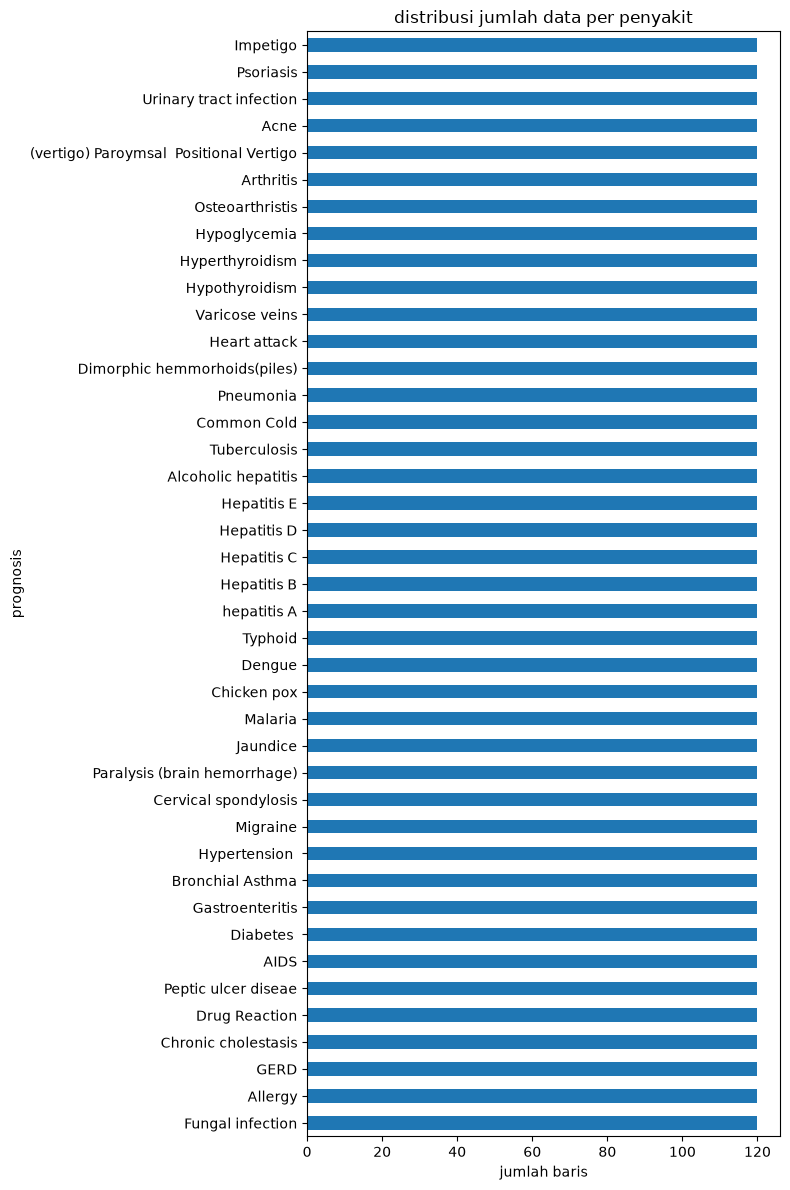

In [3]:
train["prognosis"].value_counts().plot(kind="barh", figsize=(8, 12))
plt.title("distribusi jumlah data per penyakit")
plt.xlabel("jumlah baris")
plt.tight_layout()
plt.show()

Semua 41 penyakit punya jumlah data yang **sama rata (120 baris)** — dataset ini
sengaja dibuat seimbang (*balanced*), jadi kita tidak perlu khawatir soal
class imbalance seperti kebanyakan dataset dunia nyata.

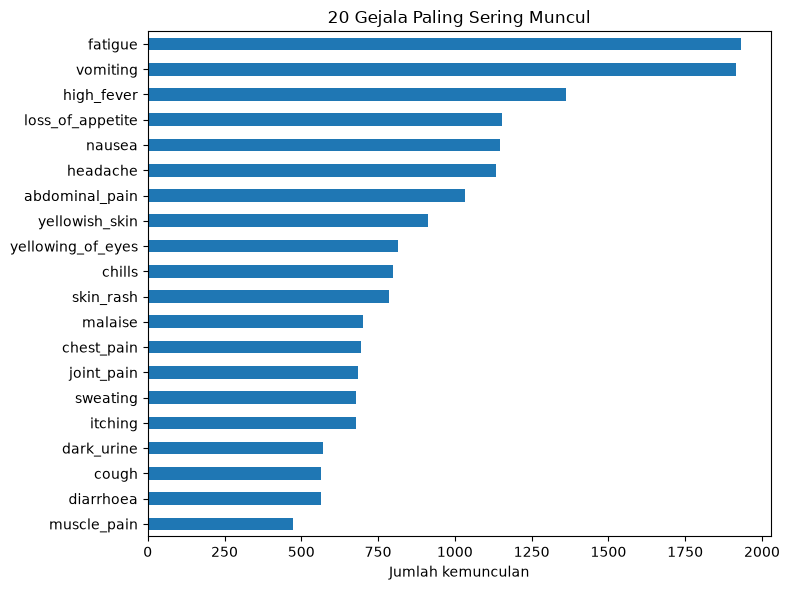

In [5]:
feature_cols = [c for c in train.columns if c != "prognosis"]
symptom_freq = train[feature_cols].sum().sort_values(ascending=False)

symptom_freq.head(20).plot(kind="barh", figsize=(8, 6))
plt.title("20 Gejala Paling Sering Muncul")
plt.xlabel("Jumlah kemunculan")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Kesimpulan EDA

- Data bersih, tidak ada missing value.
- Dataset seimbang sempurna (120 baris/penyakit).
- Hanya 304 kombinasi gejala unik — dataset bersifat deterministik/rule-based.
- Gejala paling sering: `fatigue`, `vomiting`, `high_fever` — masuk akal karena
  gejala-gejala ini bersifat umum dan muncul di banyak jenis penyakit.
- Karena sifatnya deterministik, ekspektasi akurasi model akan sangat tinggi
  (>95%) — bukan tanda model "hebat", tapi karakteristik datanya.